In [25]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.neighbors import KernelDensity
from scipy.special import logsumexp

class BayesKDE(BaseEstimator, ClassifierMixin):
  def __init__(self, bandwidth=1.0):
    self.bandwidth = bandwidth

  def fit(self, X, y):
    self.classes_ = np.unique(y)
    self.kdes_ = {}
    self.log_priors_ = {}

    for cls in self.classes_:
      kde = KernelDensity(kernel='gaussian', bandwidth=self.bandwidth)
      kde.fit(X[y == cls])
      self.kdes_[cls] = kde
      prior = np.mean(y == cls)
      self.log_priors_[cls] = np.log(prior)

    return self

  def score_log_likelihoods(self, X):
    """Returns matrix of log p(x|y) for each class y."""
    n_samples = X.shape[0]
    log_likelihoods = np.zeros((n_samples, len(self.classes_)))

    for i, cls in enumerate(self.classes_):
      log_likelihoods[:, i] = self.kdes_[cls].score_samples(X)

    return log_likelihoods

  def score_log_posteriors(self, X):
    """Returns matrix of log p(y|x) up to normalization."""
    log_likelihoods = self.score_log_likelihoods(X)
    log_posteriors = log_likelihoods + np.array([self.log_priors_[cls] for cls in self.classes_])
    return log_posteriors

  def predict(self, X):
    log_posteriors = self.score_log_posteriors(X)
    return np.argmax(log_posteriors, axis=1)

  def predict_proba(self, X):
    log_posteriors = self.score_log_posteriors(X)
    log_norm = logsumexp(log_posteriors, axis=1, keepdims=True)
    return np.exp(log_posteriors - log_norm)


In [26]:
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

def load_pima_diabetes():
  url = (
    "https://raw.githubusercontent.com/jbrownlee/Datasets/"
    "master/pima-indians-diabetes.data.csv"
  )
  cols = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
  ]
  df = pd.read_csv(url, header=None, names=cols)
  
  features = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
  
  for feat in features:
    df[feat] = df[feat].replace(0, np.nan)
    df[feat] = df[feat].fillna(df[feat].median())
  
  X = df.drop("Outcome", axis=1).values
  y = df["Outcome"].values
  return X, y

def preprocess_data(X, y):
  
  # Standardize the features
  scaler = StandardScaler()
  X_scaled = scaler.fit_transform(X)
  
  # Convert to DataFrame for easier manipulation
  X_df = pd.DataFrame(X_scaled)
  
  # Remove low variance features
  selector = VarianceThreshold(threshold=0.01)
  X_low_var_removed = selector.fit_transform(X_df)
  
  # Remove highly correlated features
  X_corr = pd.DataFrame(X_low_var_removed).corr().abs()
  upper_triangle = X_corr.where(
    np.triu(np.ones(X_corr.shape), k=1).astype(bool)
  )
  to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.9)]
  X_final = pd.DataFrame(X_low_var_removed).drop(columns=to_drop, axis=1)
  
  return X_final.values, y

X, y = load_pima_diabetes()
X, y = preprocess_data(X, y)

In [27]:
import imageio
import os
import matplotlib.pyplot as plt

def compute_likelihood(bayes_kde, X, y):
  """Compute likelihoods for each class."""
  bayes_kde.fit(X, y)
  log_likelihoods = bayes_kde.score_log_likelihoods(X)
  likelihoods = np.exp(log_likelihoods)

  # pseudo-normalize
  max_likelihoods = np.max(likelihoods)
  likelihoods = likelihoods / max_likelihoods
  
  return [likelihoods[:, i] for i in range(likelihoods.shape[1])]

def plot_likelihood(Q0, Q1, y, title="likelihood"):
  plt.scatter(Q0, Q1, c=y)
  
  plt.xlabel('Q0')
  plt.ylabel('Q1')
  plt.grid()
  plt.title(title)
  plt.show()

def make_likelihood_gif(Qs, y, filename='likelihood_animation.gif'):
  filenames = []
  for idx, (h, Q0, Q1) in enumerate(Qs):
    plt.figure()
    plt.scatter(Q0, Q1, c=y)
    plt.xlabel('Q0')
    plt.ylabel('Q1')
    plt.title(f'Bandwidth: {h:.2f}')
    plt.grid(alpha=0.3)
    
    # Save frame
    frame_filename = f'frame_{idx:03d}.png'
    plt.savefig(frame_filename, dpi=100, bbox_inches='tight')
    plt.close()
    filenames.append(frame_filename)
  
  # Create GIF
  with imageio.get_writer(filename, mode='I', duration=0.3) as writer:
    for filename in filenames:
      image = imageio.v3.imread(filename)
      writer.append_data(image)
  
  # Cleanup temporary files
  for filename in filenames:
    os.remove(filename)


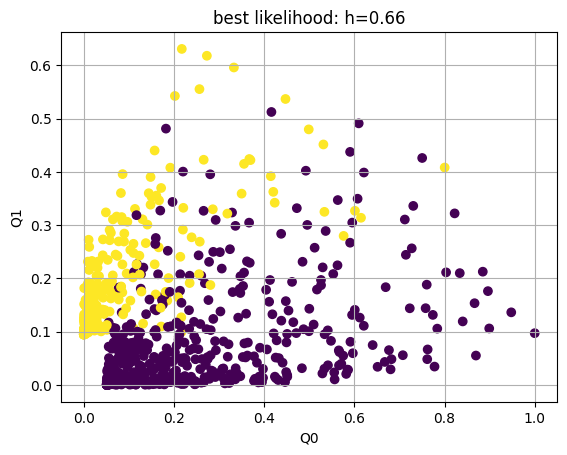

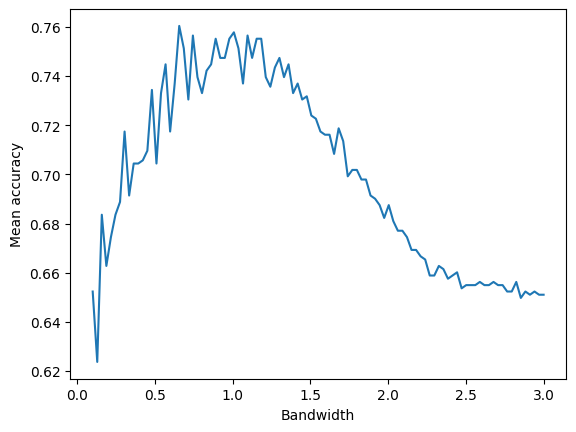

In [28]:
from sklearn.model_selection import cross_val_score, KFold

hs = np.linspace(0.1, 3, 100)

kf = KFold(n_splits=3, shuffle=True)
mean_scores = []
Qs = []

for h in hs:
  bayeskde = BayesKDE(bandwidth=h)
  scores = cross_val_score(bayeskde, X, y, cv=kf, scoring='accuracy')
  mean_scores.append(np.mean(scores))

  Q0, Q1 = compute_likelihood(bayeskde, X, y)
  Qs.append((h, Q0, Q1))

best_h = hs[np.argmax(mean_scores)]
best_bayeskde = BayesKDE(bandwidth=best_h)
best_Q0, best_Q1 = compute_likelihood(best_bayeskde, X, y)
plot_likelihood(best_Q0, best_Q1, y, title=f"best likelihood: h={best_h:.2f}")

# make_likelihood_gif(Qs, y)

plt.figure()
plt.plot(hs, mean_scores)
plt.xlabel('Bandwidth')
plt.ylabel('Mean accuracy')
plt.savefig('bandwidth_vs_accuracy.png')
plt.show()


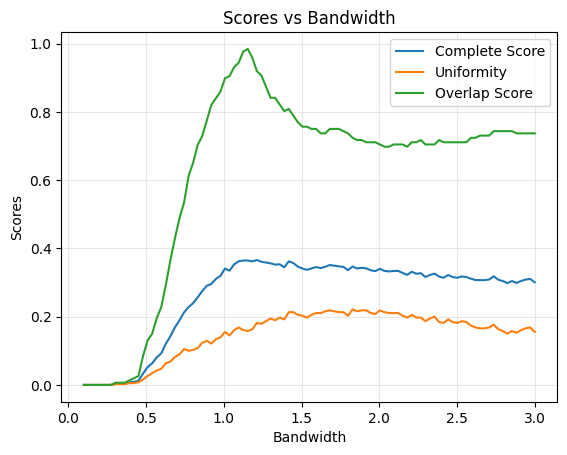

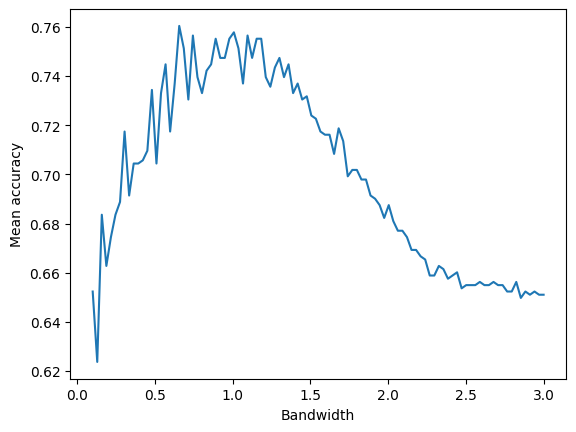

In [ ]:
Qs_dict = {h: np.column_stack((Q0, Q1)) for h, Q0, Q1 in Qs}

def uniformity_overlap_score(Q, y, overlap_desired_proportion, uniformity_weight, m=20):
  """
  Parameters:
    Q: array-like, shape (n_samples, 2)
     Each row is a point (x, y), assumed within [0,1]^2.
    y: array-like of ints (0 or 1), shape (n_samples,)
     True class of each point.
    overlap_desired_proportion: float in (0,1)
     Overlap up to this fraction is rewarded; beyond it is penalized.
    uniformity_weight: float in (0,1)
      Weight of uniformity in the final score.
    m: int, optional (default=20)
     Number of bins per axis when estimating uniformity.

  Returns:
    complete: float
    Joint score = uniformity * overlap_score.
    uniformity: float
    Mean of the two regional uniformity scores.
    overlap_score: float
    Overlap reward/penalty in [0,1].
  """
  Q = np.asarray(Q)
  x, y_coords = Q[:,0], Q[:,1]
  labels = np.asarray(y)
  n = len(labels)
  if not (0 < overlap_desired_proportion < 1):
    raise ValueError("desired_proportion must be between 0 and 1.")

  # Precompute bin centers
  edges = np.linspace(0, 1, m+1)
  centers = (edges[:-1] + edges[1:]) / 2
  cx, cy = np.meshgrid(centers, centers)

  uniformities = []
  # For each class, compute uniformity in its triangular region
  for cls in (0, 1):
    pts = Q[labels == cls]
    if cls == 0:
      # Region 0: x > y
      region_mask = cx > cy
    else:
      # Region 1: y > x
      region_mask = cy > cx

    # Total bins in this triangle
    total_bins = np.count_nonzero(region_mask)

    # Build a 2D histogram over the full square
    H, _, _ = np.histogram2d(pts[:,0], pts[:,1], bins=(edges, edges))
    # Count how many of the triangle's bins are non-empty
    nonempty = np.count_nonzero((H > 0) & region_mask)

    uniformities.append(nonempty / total_bins if total_bins > 0 else 0.0)

  uniformity = np.mean(uniformities)

  # --- Overlap calculation ---
  # Count how many S0 lie in region 1, and vice versa
  mask_region0 = (x > y_coords)
  mask_region1 = (y_coords > x)
  overlap_count = np.sum((labels == 0) & mask_region1) + np.sum((labels == 1) & mask_region0)
  actual_overlap = overlap_count / n

  overlap_score = 1 - np.abs(actual_overlap - overlap_desired_proportion) / overlap_desired_proportion
  overlap_score = np.clip(overlap_score, 0.0, 1.0)

  overlap_weight = 1 - uniformity_weight

  complete = uniformity_weight * uniformity + overlap_weight * overlap_score

  return complete, uniformity, overlap_score

scores = []

for h in Qs_dict:
  Q = Qs_dict[h]
  score, uniformity, overlap_score = uniformity_overlap_score(Q, y, overlap_desired_proportion=0.175, uniformity_weight=0.5)
  scores.append((h, score, uniformity, overlap_score))

scores = np.array(scores)
plt.figure()
plt.plot(scores[:, 0], scores[:, 1], label='Complete Score')
plt.plot(scores[:, 0], scores[:, 2], label='Uniformity')
plt.plot(scores[:, 0], scores[:, 3], label='Overlap Score')
plt.xlabel('Bandwidth')
plt.ylabel('Scores')
plt.legend()
plt.title('Scores vs Bandwidth')
plt.grid(alpha=0.3)
plt.show()

plt.figure()
plt.plot(hs, mean_scores)
plt.xlabel('Bandwidth')
plt.ylabel('Mean accuracy')
plt.savefig('bandwidth_vs_accuracy.png')
plt.show()